In [34]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from tools.rsa import compute_similarity
from models.admm import ADMM
from utils.helpers import median_matrix_split, best_pairwise_match, zero_matrix_split
from utils.plotting import plot_images_from_embedding
import seaborn as sns
import pandas as pd
from pathlib import Path


# df_similarity = pd.read_csv("../results/cross_validation/rank_detection.csv")
# df_training = pd.read_csv("../results/cross_validation/rank_recovery.csv")

df_simulation = pd.read_csv("../results/cross_validation/rank_experiment_simulation.csv")








The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
df_simulation


,n_objects,true_rank,observed_fraction,snr,rho,max_outer,max_inner,trial_id,best_rank,best_score,rank_correct,rank_error,seed,similarity_measure
0,100,10,0.8,1.0,1.0,10,50,0,10,0.000648,True,0,0,linear
1,100,10,0.8,1.0,1.0,10,50,1,10,0.000488,True,0,1,linear
2,100,10,0.8,1.0,1.0,10,50,2,10,0.000898,True,0,2,linear
3,100,10,0.8,1.0,1.0,10,50,3,10,0.000516,True,0,3,linear
4,100,10,0.8,1.0,1.0,10,50,4,10,0.000855,True,0,4,linear


In [30]:
# Check the exact values in your data
test = df_simulation[df_simulation["true_rank"] == 10]
print("Exact observed_fraction values:")
for val in test["observed_fraction"].unique():
    print(f"{val:.17f}")  # Show full precision

# The problem: 0.8 might be stored as 0.7999999999999999 or similar
# Here are two solutions:

# Solution 1: Use np.isclose() for comparison
test_solution1 = test[np.isclose(test["observed_fraction"], 0.8, atol=1e-10)]
print(f"\nSolution 1 - Number of rows with np.isclose: {len(test_solution1)}")

# Solution 2: Round the values before comparison
test_solution2 = test[test["observed_fraction"].round(1) == 0.8]
print(f"Solution 2 - Number of rows with rounding: {len(test_solution2)}")


Exact observed_fraction values:
0.20000000000000001
0.29999999999999999
0.40000000000000002
0.50000000000000000
0.59999999999999998
0.69999999999999996
0.80000000000000004

Solution 1 - Number of rows with np.isclose: 20
Solution 2 - Number of rows with rounding: 20


/LOCAL/fmahner/similarity-factorization/.venv/lib/python3.11/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/LOCAL/fmahner/similarity-factorization/.venv/lib/python3.11/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


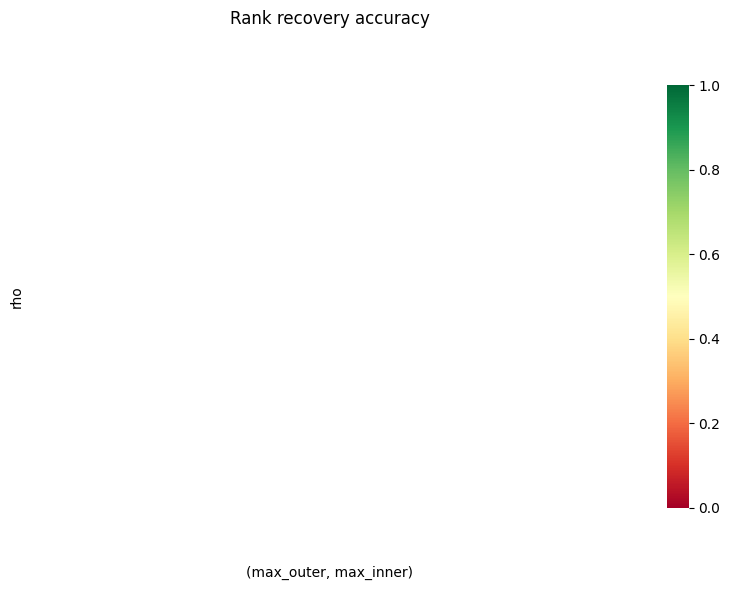

In [ ]:
five = df_simulation[
    (df_simulation["true_rank"] == 5) & (df_simulation["n_objects"] == 50)
]

# Create heatmap of rank recovery accuracy for all parameter combinations
pivot_data = five.pivot_table(
    values="rank_correct",
    index="rho",
    columns=["max_outer", "max_inner"],
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Rank recovery accuracy")
ax.set_xlabel("(max_outer, max_inner)")
ax.set_ylabel("rho")

plt.tight_layout()
plt.show()


### Below we check if there is a power law or somethig similar between the nuber of objects and the optimal training ratio

<Figure size 960x720 with 0 Axes>

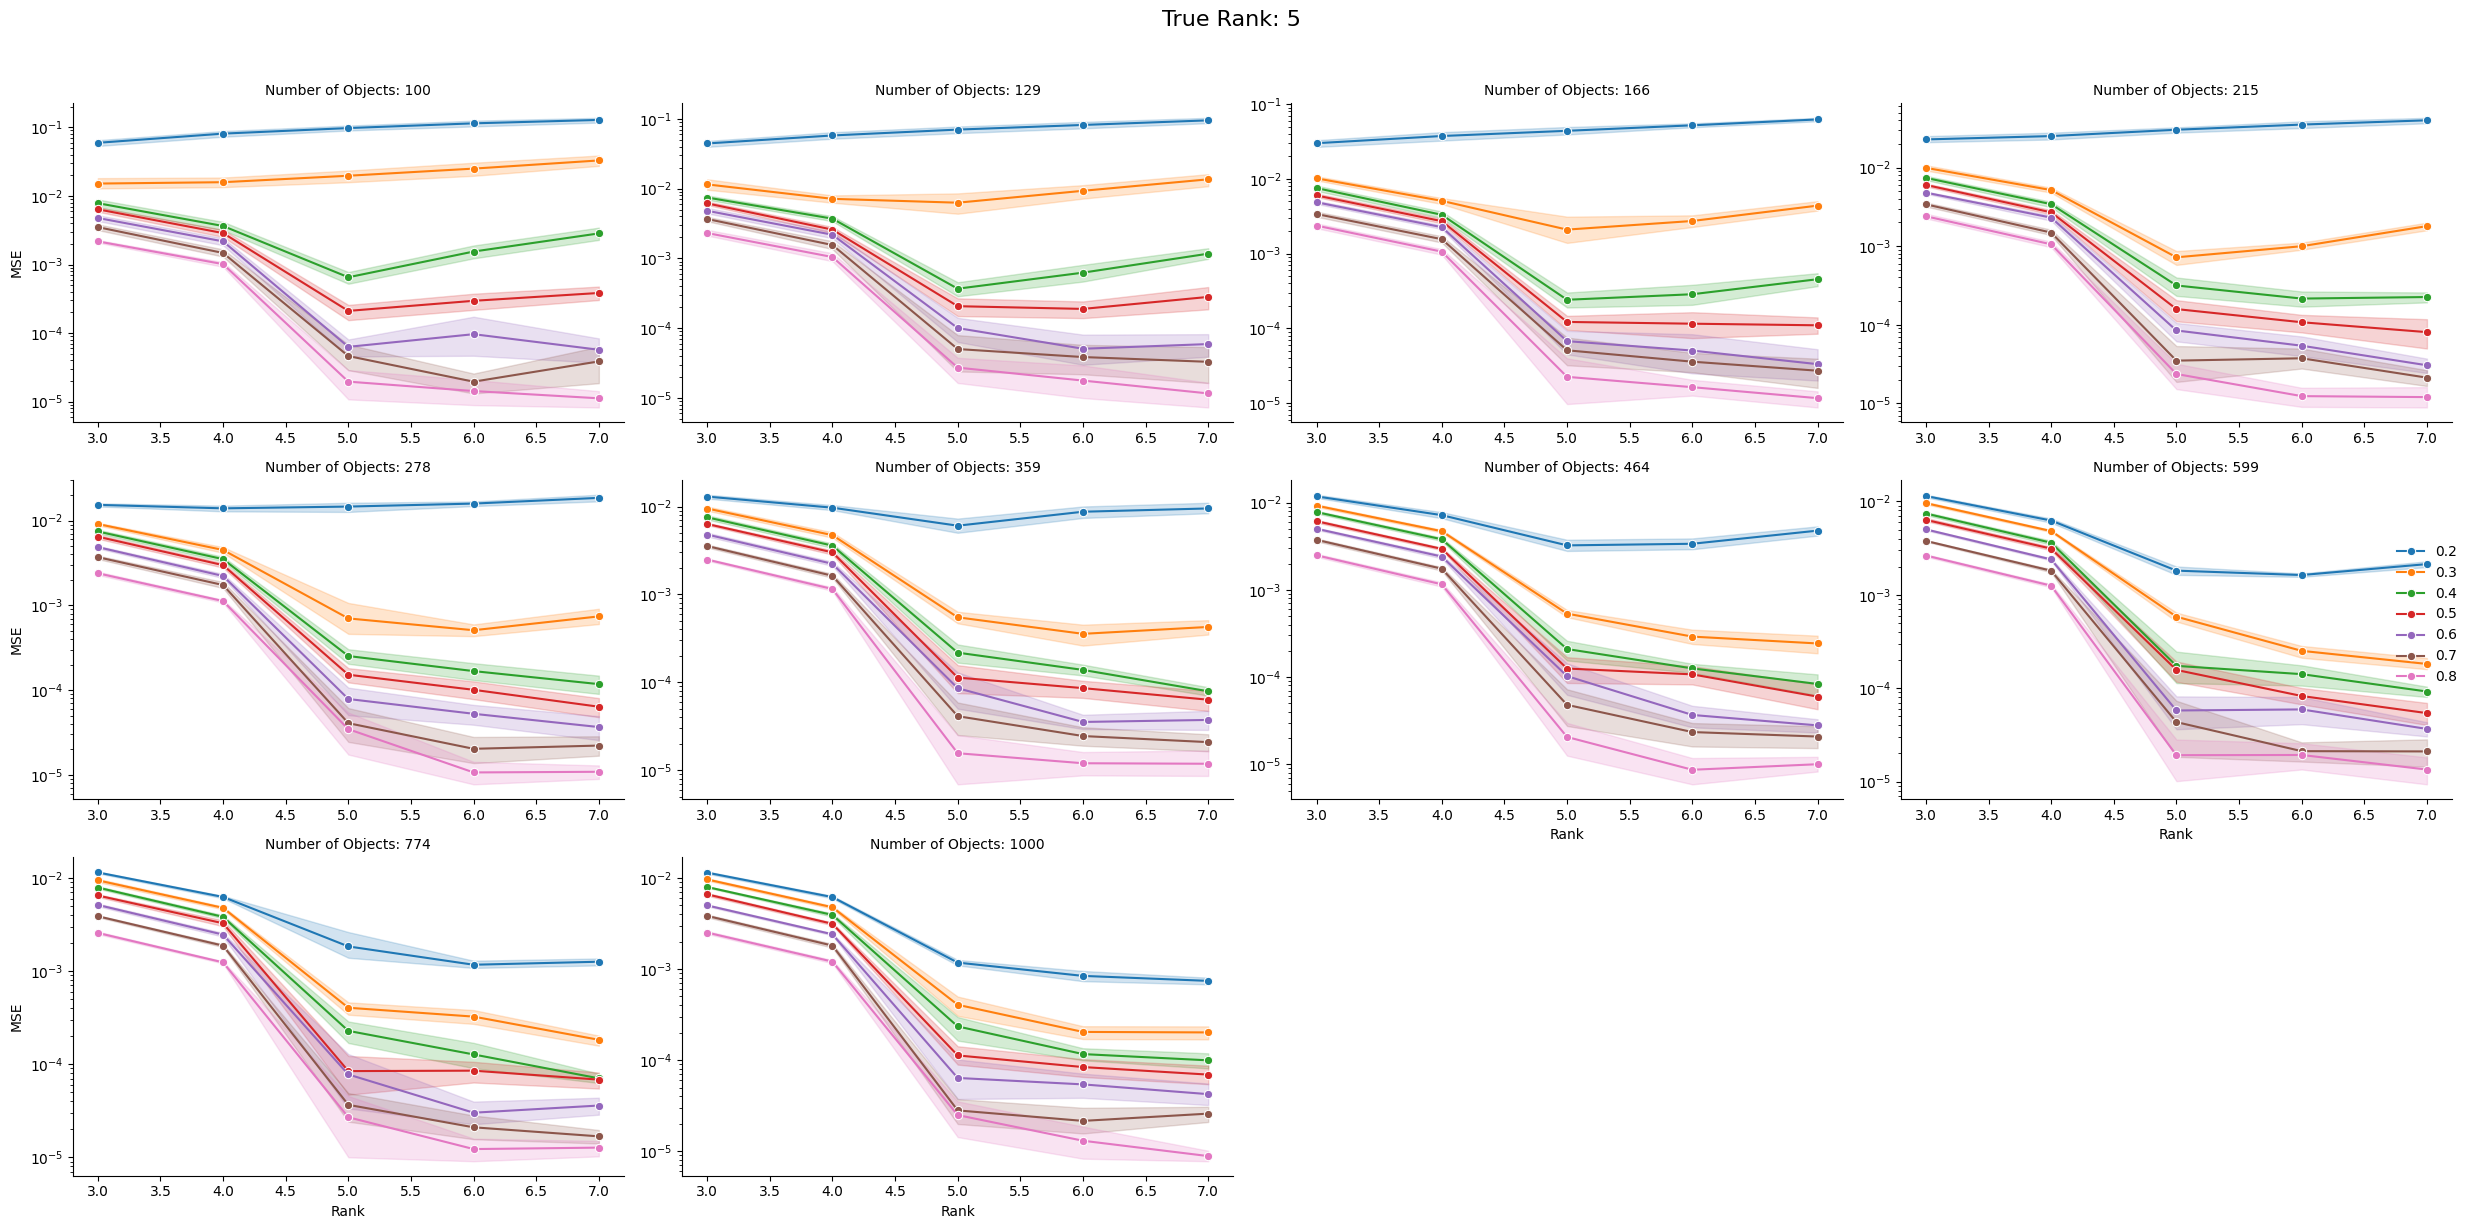

<Figure size 960x720 with 0 Axes>

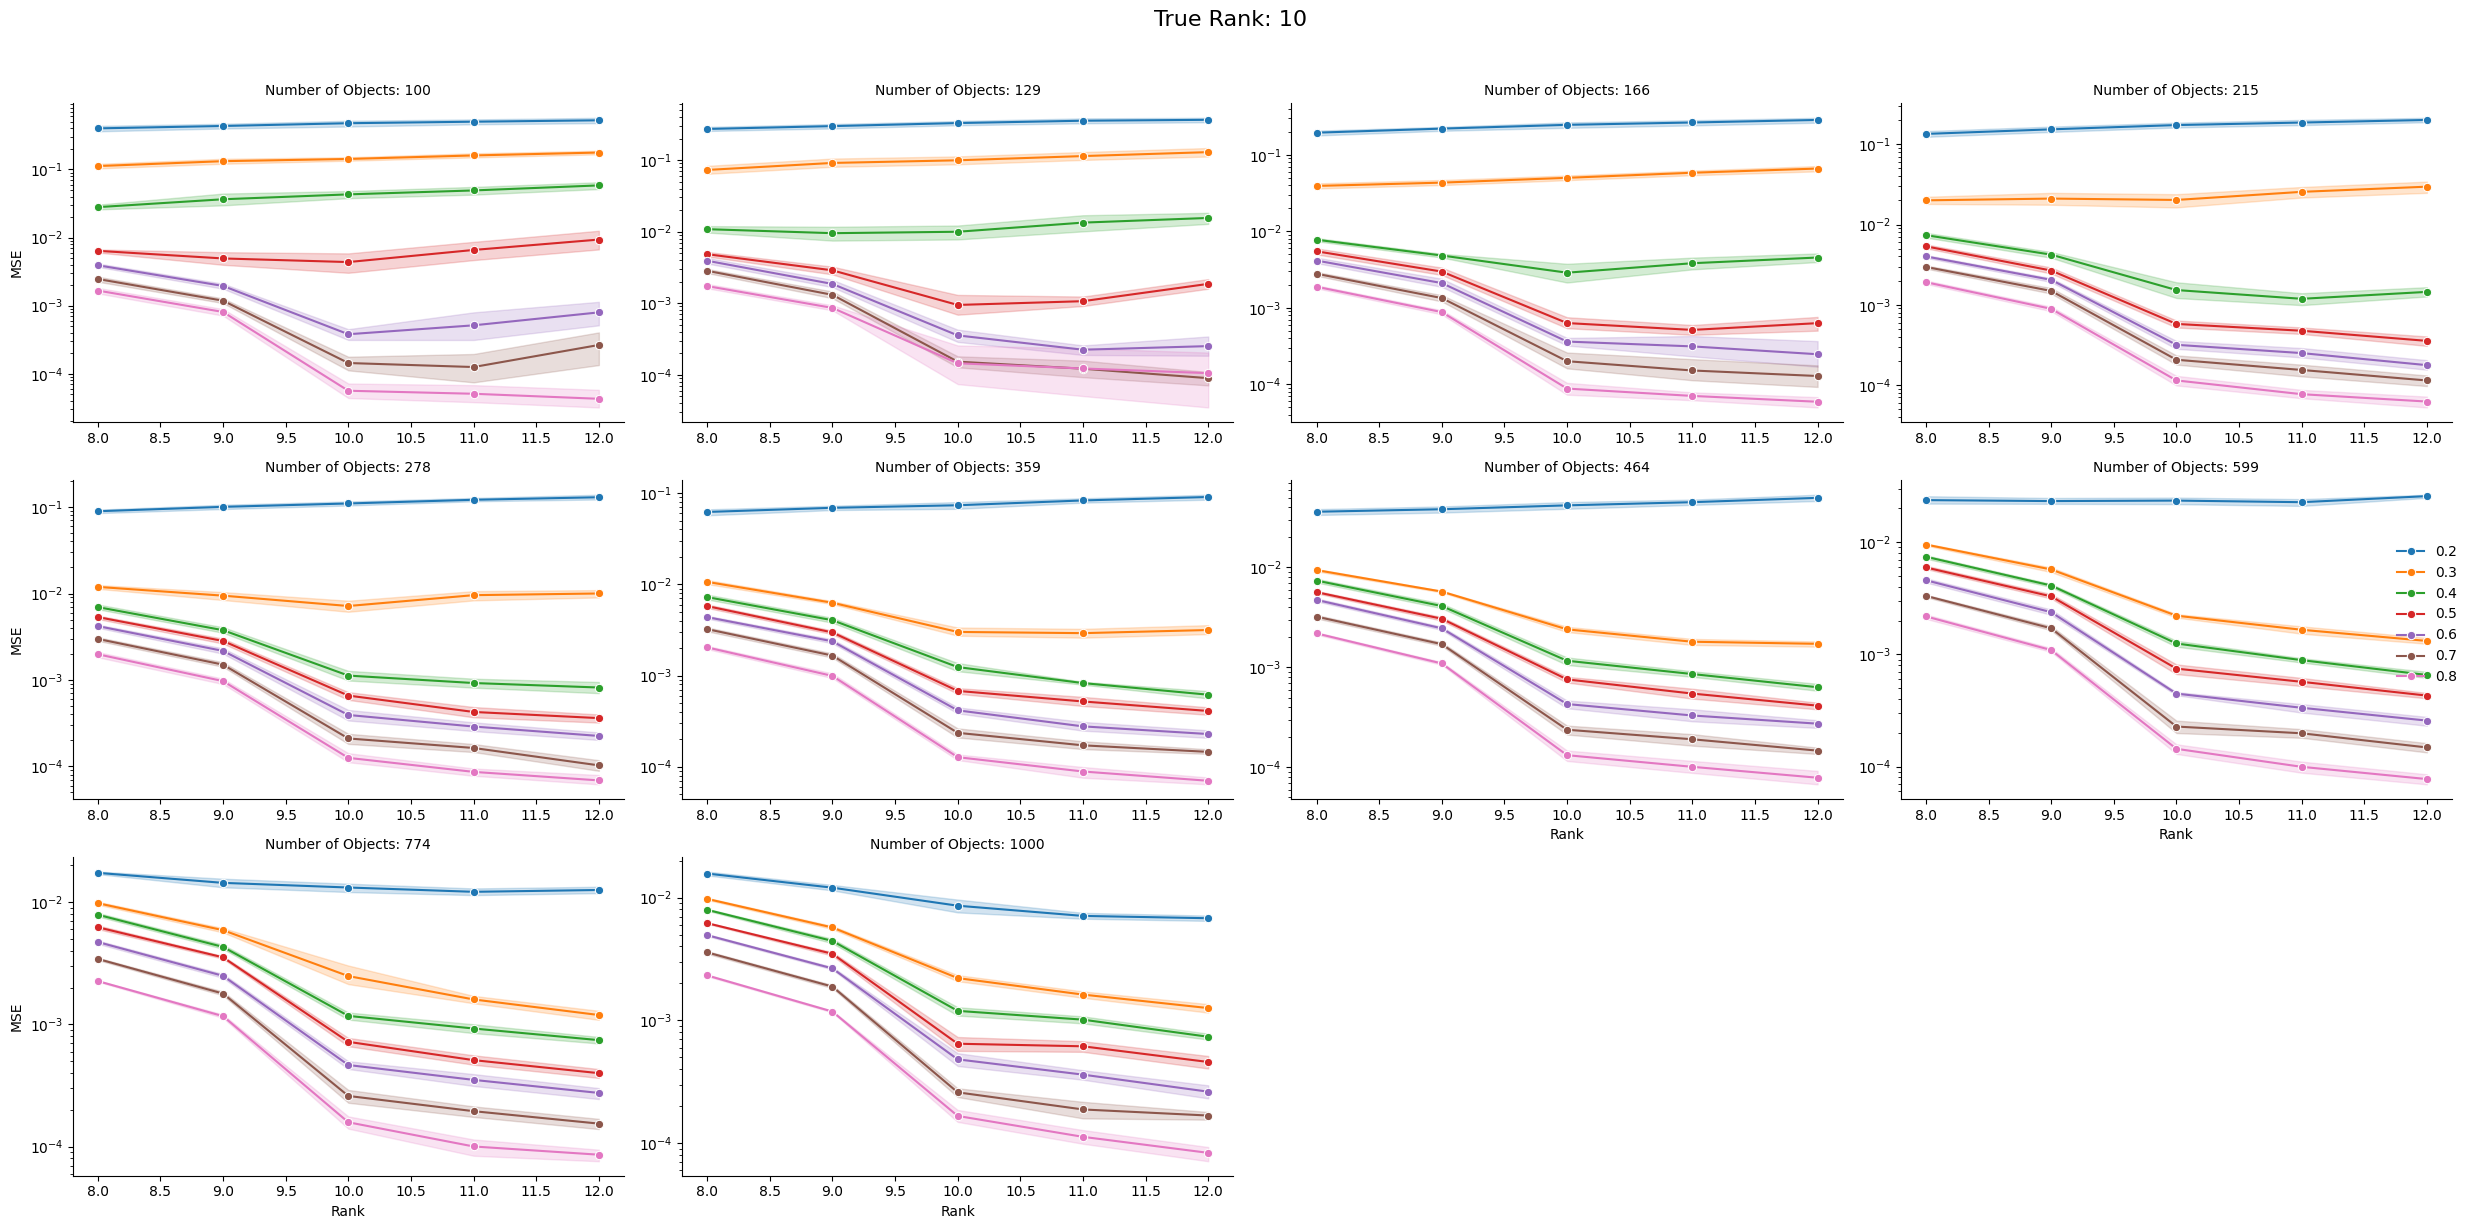

<Figure size 960x720 with 0 Axes>

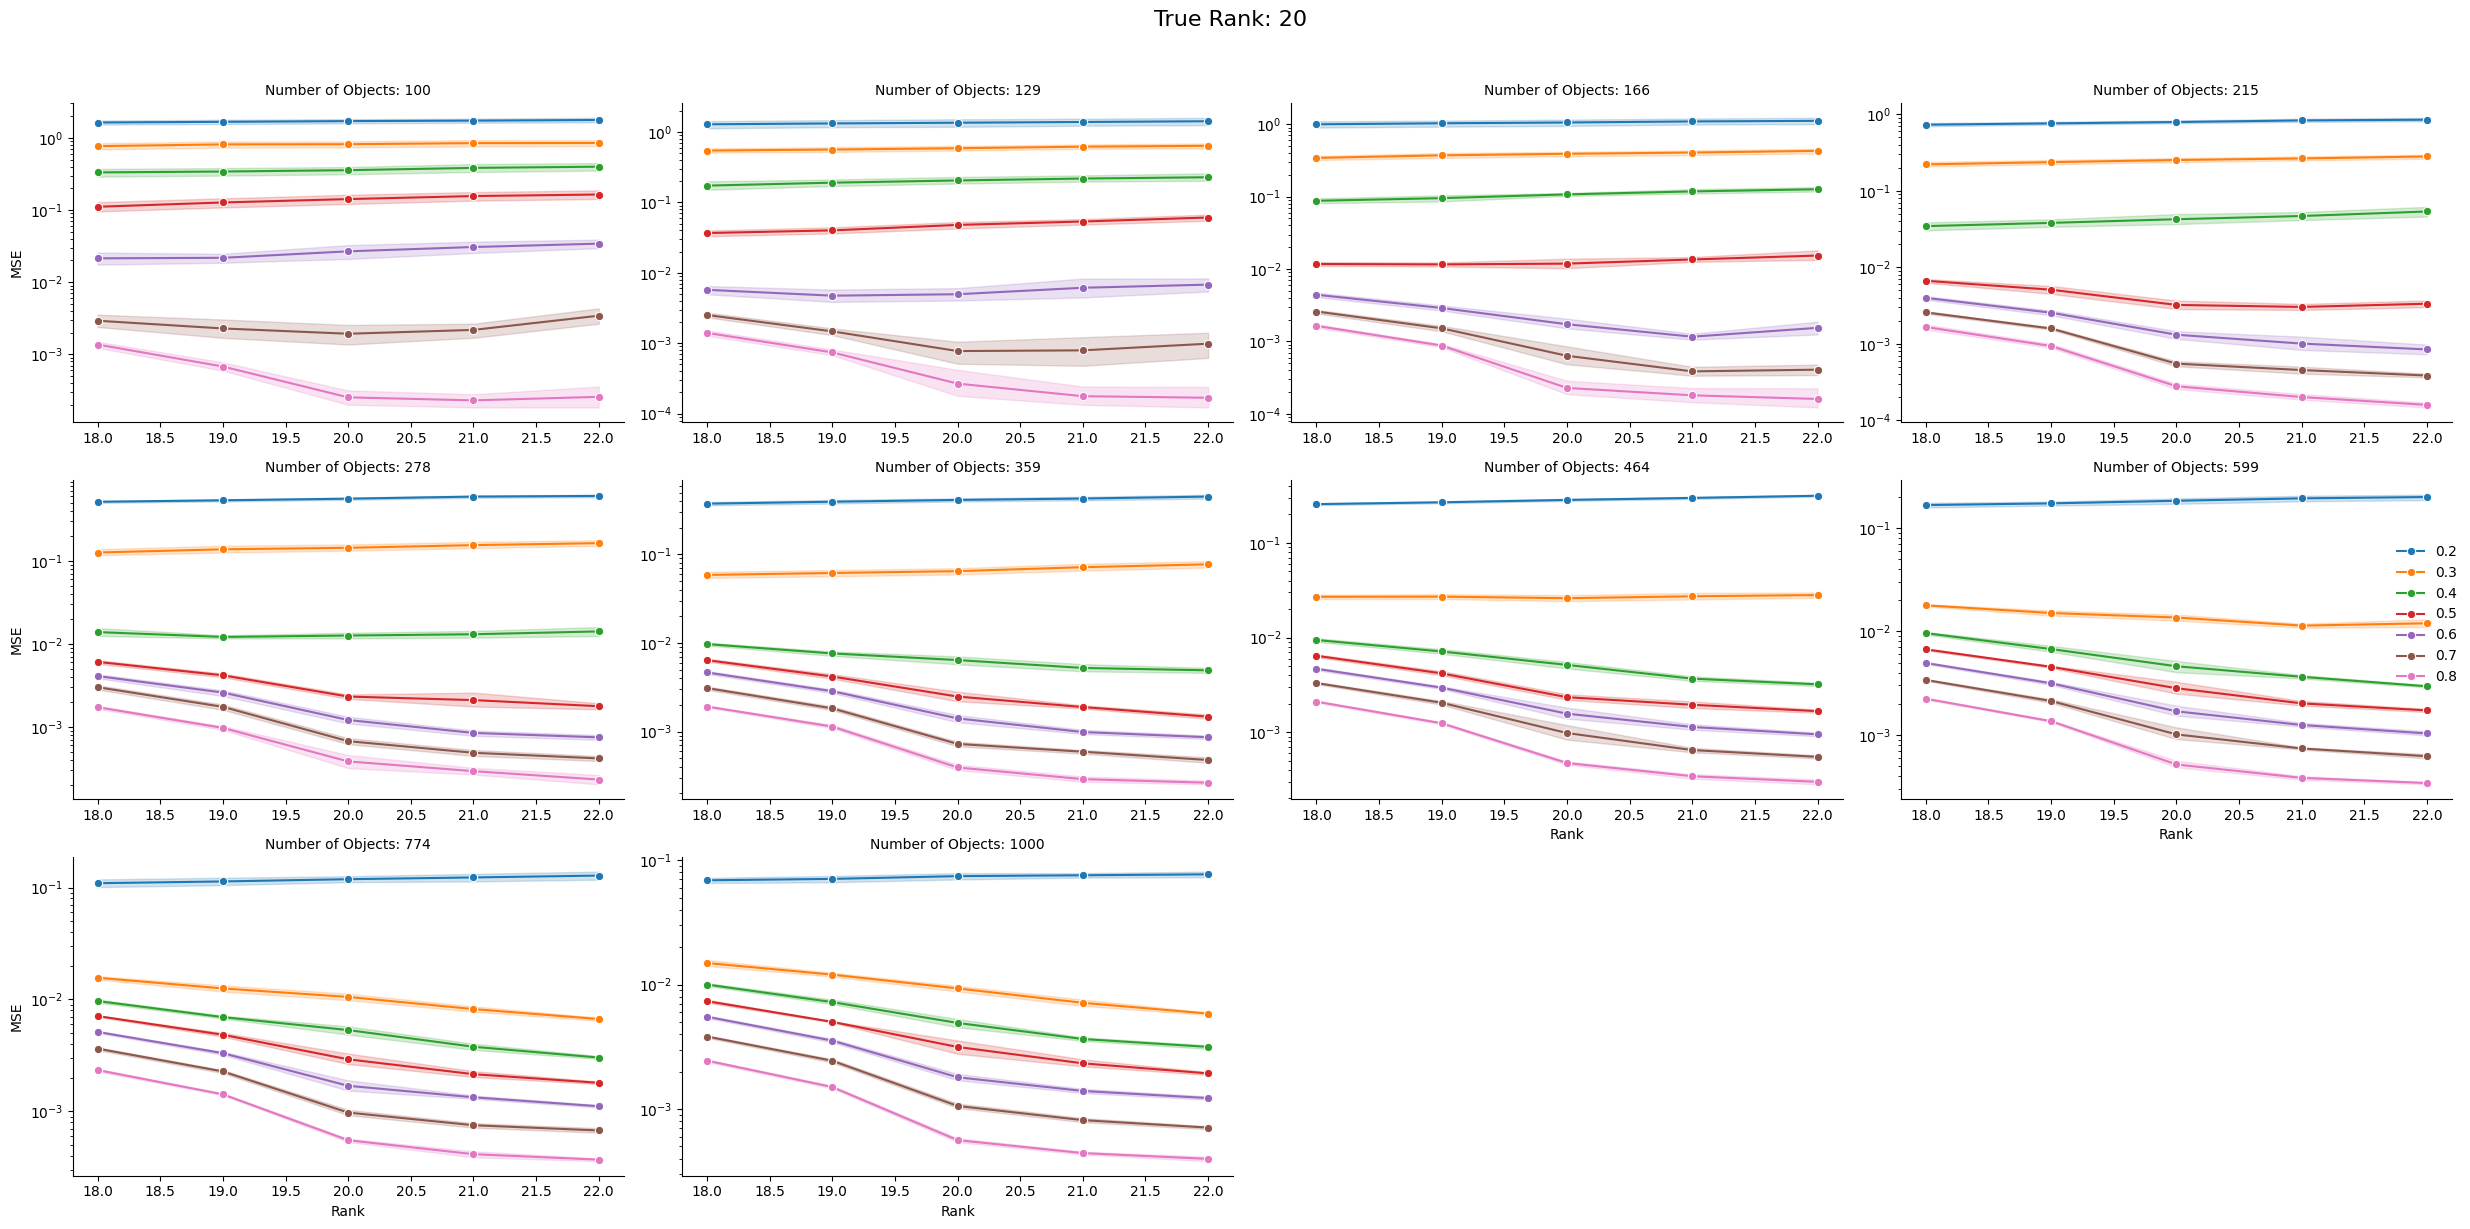

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = df_similarity[df_similarity["snr"] == 1.0]

unique_true_ranks = sorted(df["true_rank"].unique())

for true_rank in unique_true_ranks:
    df_subset = df[df["true_rank"] == true_rank]

    plt.figure(dpi=150)
    g = sns.FacetGrid(
        df_subset,
        col="n_objects",
        col_wrap=4,
        height=4,
        aspect=1.5,
        sharey=False,
        sharex=False,
    )
    g.map_dataframe(
        sns.lineplot,
        x="rank",
        y="mse",
        hue="observed_fraction",
        marker="o",
        palette="tab10",
    )
    g.add_legend()
    g.set_axis_labels("Rank", "MSE")
    g.set_titles("Number of Objects: {col_name}")

    for ax in g.axes.flat:
        ax.set_yscale("log")

    plt.suptitle(f"True Rank: {true_rank}", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()


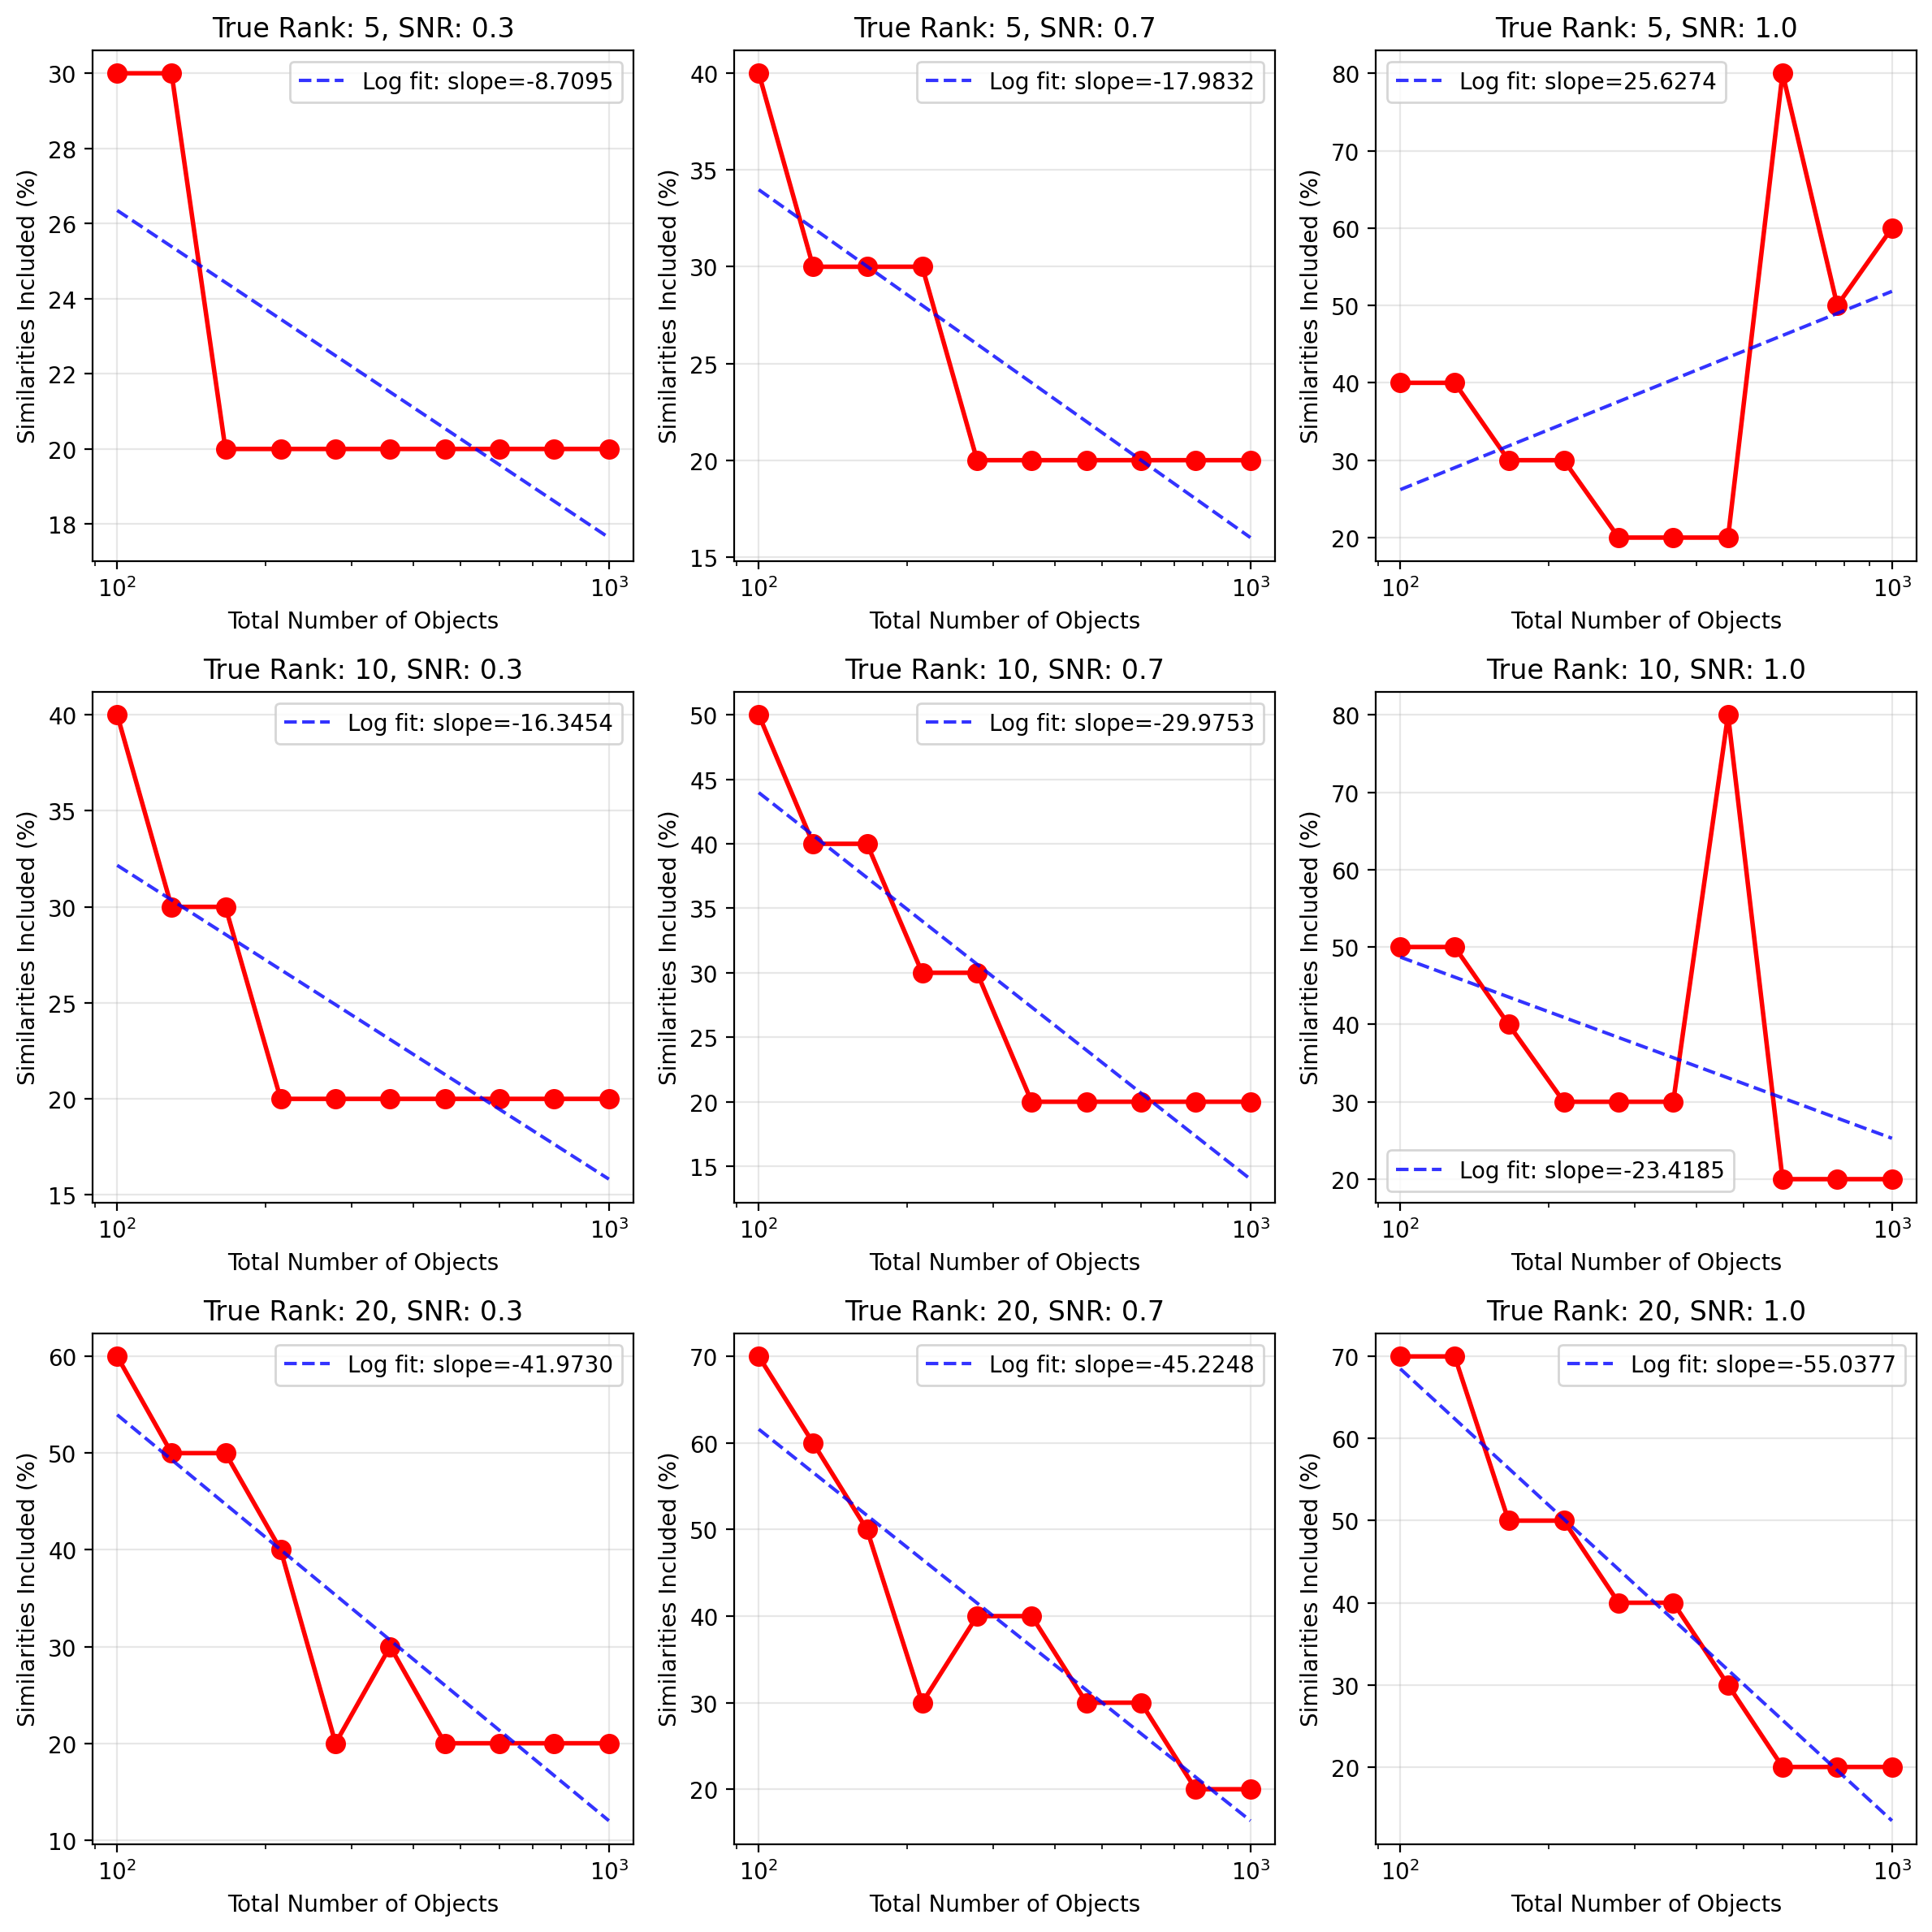

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = df_similarity


def plot_optimal_ratios(df_subset, true_rank, snr):
    best_ranks = df_subset.groupby(["n_objects", "observed_fraction", "trial_id"])[
        "mse"
    ].idxmin()
    best_ranks_df = df_subset.loc[best_ranks]

    best_ranks_df["correct_rank"] = best_ranks_df["rank"] == best_ranks_df["true_rank"]
    accuracy_df = (
        best_ranks_df.groupby(["n_objects", "observed_fraction"])["correct_rank"]
        .mean()
        .reset_index()
    )

    optimal_ratios = []
    object_counts = []

    for n_obj in sorted(df_subset["n_objects"].unique()):
        subset = accuracy_df[accuracy_df["n_objects"] == n_obj]
        best_ratio = subset.loc[subset["correct_rank"].idxmax(), "observed_fraction"]
        optimal_ratios.append(best_ratio)
        object_counts.append(n_obj)

    plt.plot(
        object_counts,
        np.array(optimal_ratios) * 100,
        "o-",
        linewidth=2,
        markersize=8,
        color="red",
    )

    z = np.polyfit(np.log10(object_counts), np.array(optimal_ratios) * 100, 1)
    p = np.poly1d(z)
    plt.plot(
        object_counts,
        p(np.log10(object_counts)),
        "--",
        alpha=0.8,
        color="blue",
        label=f"Log fit: slope={z[0]:.4f}",
    )

    plt.xlabel("Total Number of Objects")
    plt.ylabel("Similarities Included (%)")
    plt.title(f"True Rank: {true_rank}, SNR: {snr}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xscale("log")


unique_true_ranks = sorted(df["true_rank"].unique())
unique_snrs = sorted(df["snr"].unique())

fig, axes = plt.subplots(
    len(unique_true_ranks),
    len(unique_snrs),
    figsize=(4 * len(unique_snrs), 4 * len(unique_true_ranks)),
    dpi=200,
)

for i, true_rank in enumerate(unique_true_ranks):
    for j, snr in enumerate(unique_snrs):
        df_subset = df[(df["true_rank"] == true_rank) & (df["snr"] == snr)]

        if len(df_subset) > 0:
            ax = axes[i, j] if len(unique_true_ranks) > 1 else axes[j]
            plt.sca(ax)
            plot_optimal_ratios(df_subset, true_rank, snr)

plt.tight_layout()
plt.show()


In [40]:
df = df_similarity

best_ranks = df.groupby(
    ["n_objects", "observed_fraction", "true_rank", "snr", "trial_id"]
)["mse"].idxmin()
best_ranks_df = df.loc[best_ranks]

best_ranks_df["correct_rank"] = best_ranks_df["rank"] == best_ranks_df["true_rank"]

accuracy_df = (
    best_ranks_df.groupby(["true_rank", "snr", "observed_fraction"])["correct_rank"]
    .agg(["mean", "std"])
    .reset_index()
)
accuracy_df.columns = [
    "true_rank",
    "snr",
    "observed_fraction",
    "accuracy",
    "accuracy_std",
]
accuracy_df


,true_rank,snr,observed_fraction,accuracy,accuracy_std
0,5,0.3,0.2,0.14,0.348735
1,5,0.3,0.3,0.12,0.326599
2,5,0.3,0.4,0.00,0.000000
3,5,0.3,0.5,0.00,0.000000
4,5,0.3,0.6,0.00,0.000000
...,...,...,...,...,...
58,20,1.0,0.4,0.04,0.196946
59,20,1.0,0.5,0.08,0.272660
60,20,1.0,0.6,0.04,0.196946
61,20,1.0,0.7,0.08,0.272660


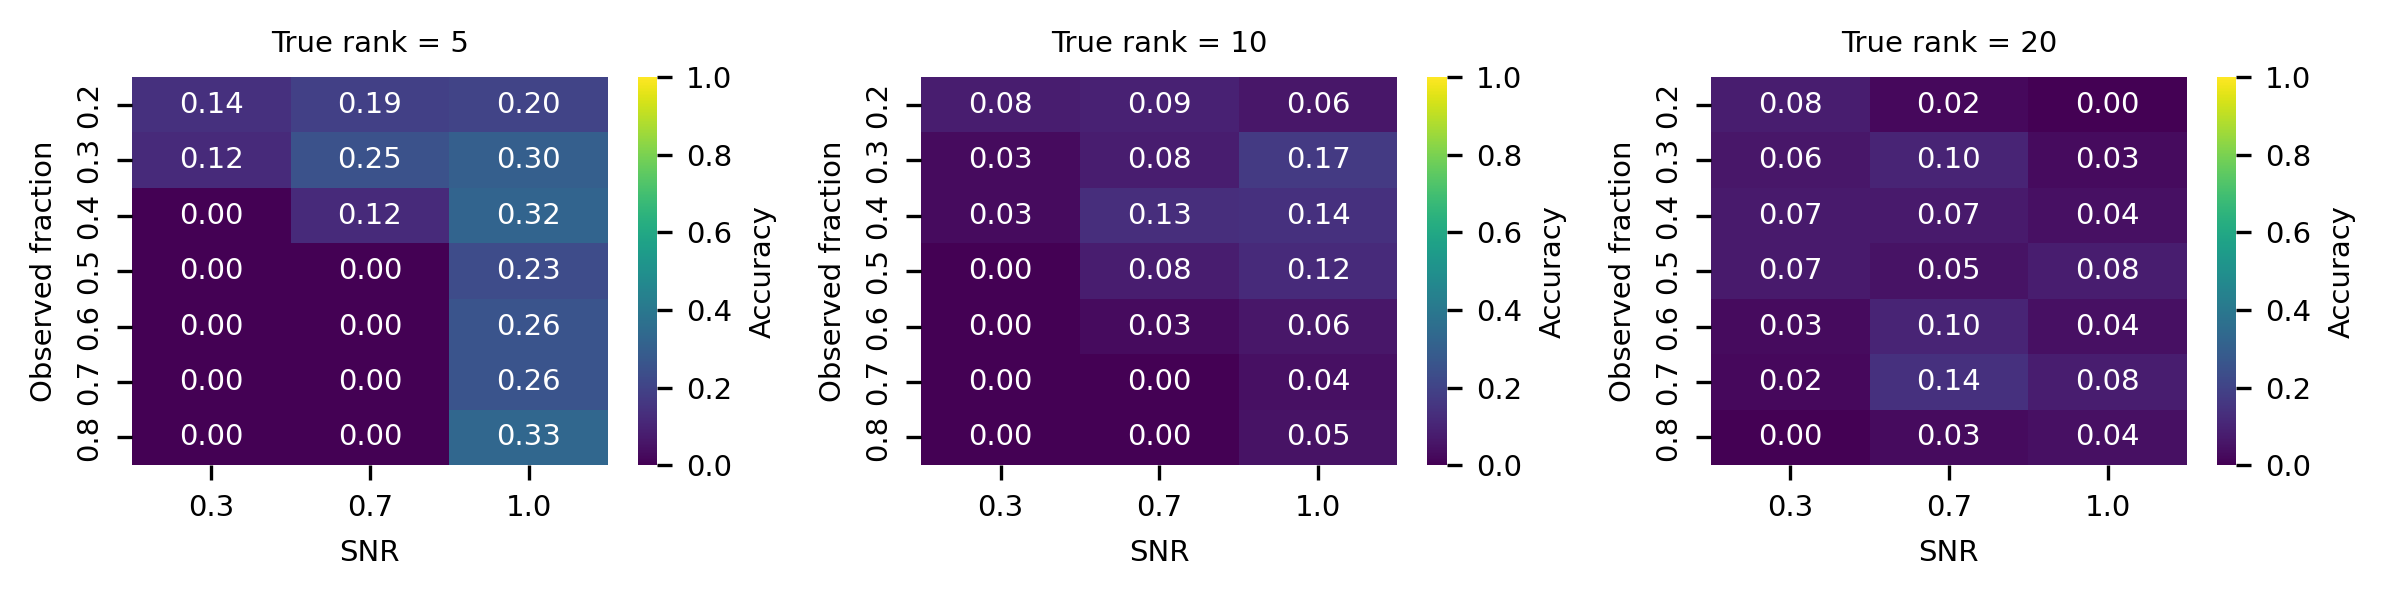

In [58]:
plt.rcParams.update({"font.size": 7})

fig, axes = plt.subplots(1, 3, figsize=(8, 2), dpi=300)

for i, true_rank in enumerate([5, 10, 20]):
    subset = accuracy_df[accuracy_df["true_rank"] == true_rank]

    pivot_data = subset.pivot_table(
        values="accuracy", index="observed_fraction", columns="snr", aggfunc="mean"
    )

    sns.heatmap(
        pivot_data,
        ax=axes[i],
        cmap="viridis",
        annot=True,
        fmt=".2f",
        cbar_kws={"label": "Accuracy"},
        vmin=0,
        vmax=1,
    )
    axes[i].set_title(f"True rank = {true_rank}", fontsize=7)
    axes[i].set_xlabel("SNR", fontsize=7)
    axes[i].set_ylabel("Observed fraction", fontsize=7)

plt.tight_layout()
plt.show()


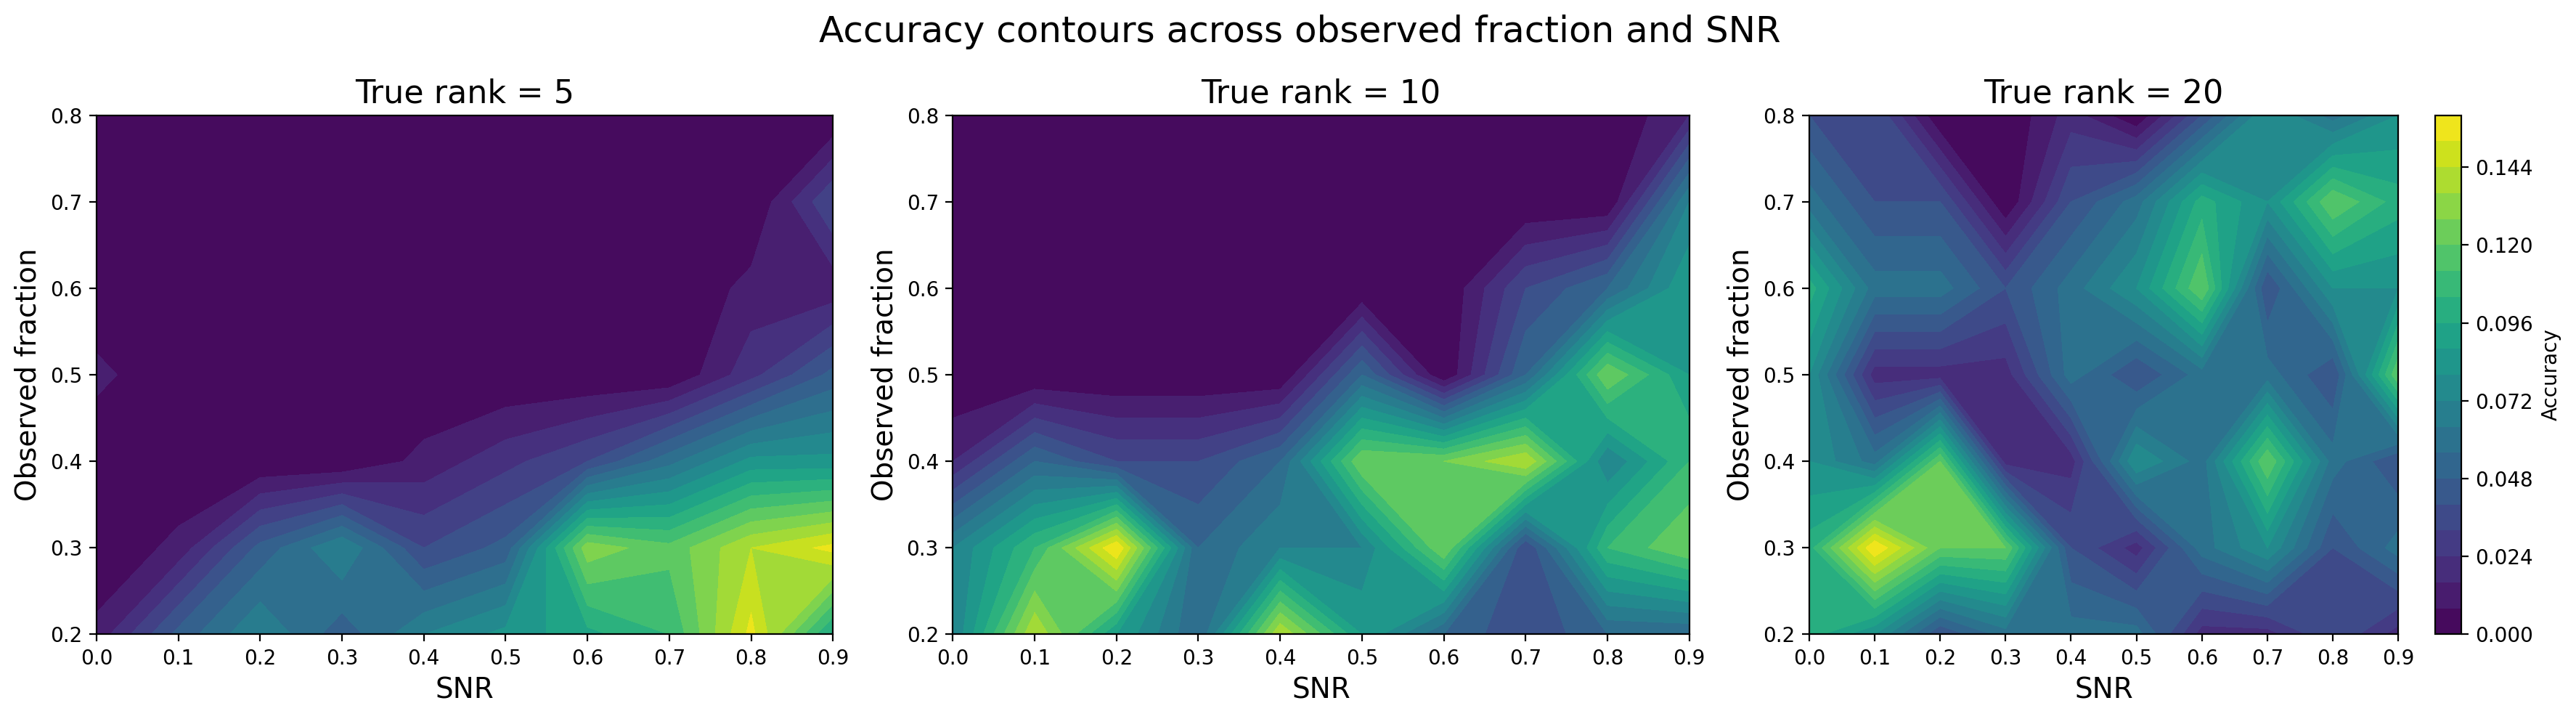

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=200)

for i, true_rank in enumerate([5, 10, 20]):
    subset = accuracy_df[accuracy_df["true_rank"] == true_rank]

    pivot_data = (
        subset.groupby(["observed_fraction", "snr"])["accuracy"].mean().unstack()
    )

    im = axes[i].contourf(
        pivot_data.columns,
        pivot_data.index,
        pivot_data.values,
        levels=20,
        cmap="viridis",
    )
    axes[i].set_xlabel("SNR", fontsize=14)
    axes[i].set_ylabel("Observed fraction", fontsize=14)
    axes[i].set_title(f"True rank = {true_rank}", fontsize=16)

    if i == 2:
        plt.colorbar(im, ax=axes[i], label="Accuracy")

plt.suptitle("Accuracy contours across observed fraction and SNR", fontsize=18)
plt.tight_layout()
plt.show()


In [ ]:
df = pd.read_csv("../results/rank_detection_results.csv")

best_ranks = df.groupby(
    ["n_objects", "observed_fraction", "true_rank", "snr", "trial_id"]
)["mse"].idxmin()
best_ranks_df = df.loc[best_ranks]
best_ranks_df["correct_rank"] = best_ranks_df["rank"] == best_ranks_df["true_rank"]

accuracy_df = (
    best_ranks_df.groupby(["n_objects", "observed_fraction", "true_rank", "snr"])[
        "correct_rank"
    ]
    .mean()
    .reset_index()
)


/LOCAL/fmahner/similarity-factorization/.venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/LOCAL/fmahner/similarity-factorization/.venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/LOCAL/fmahner/similarity-factorization/.venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


<Figure size 3000x800 with 0 Axes>

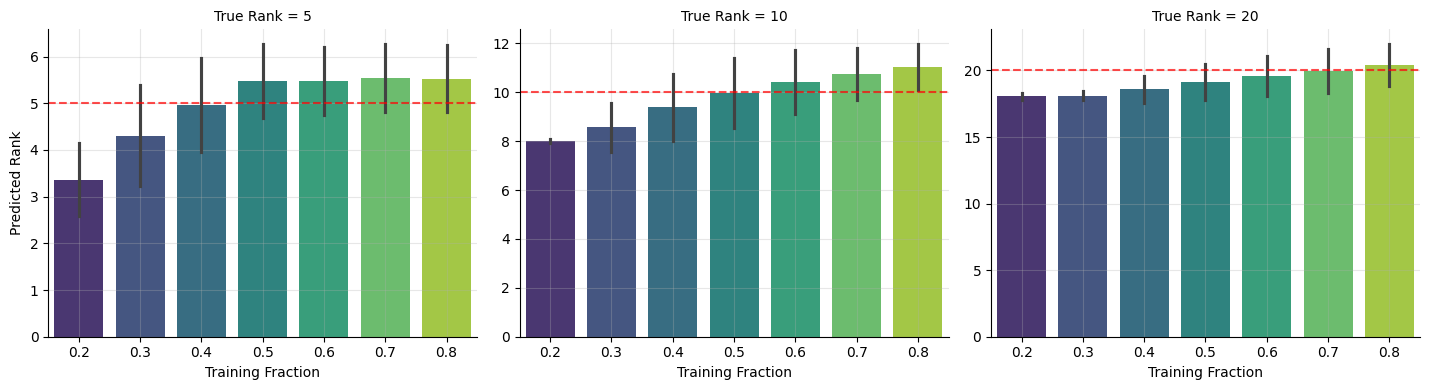

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../results/rank_detection_results.csv")

predicted_ranks = df.loc[
    df.groupby(["n_objects", "train_ratio", "trial_id", "true_rank"])["mse"].idxmin()
][["n_objects", "train_ratio", "trial_id", "true_rank", "rank", "mse"]].copy()

predicted_ranks = predicted_ranks.rename(columns={"rank": "predicted_rank"})

plt.figure(figsize=(15, 4), dpi=200)
g = sns.FacetGrid(
    predicted_ranks,
    col="true_rank",
    height=4,
    aspect=1.2,
    sharey=False,
)
g.map_dataframe(
    sns.barplot,
    x="train_ratio",
    y="predicted_rank",
    errorbar="sd",
    palette="viridis",
)
g.set_axis_labels("Training Fraction", "Predicted Rank")
g.set_titles("True Rank = {col_name}")

for ax, true_rank in zip(g.axes.flat, sorted(predicted_ranks["true_rank"].unique())):
    ax.axhline(y=true_rank, color="red", linestyle="--", alpha=0.7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


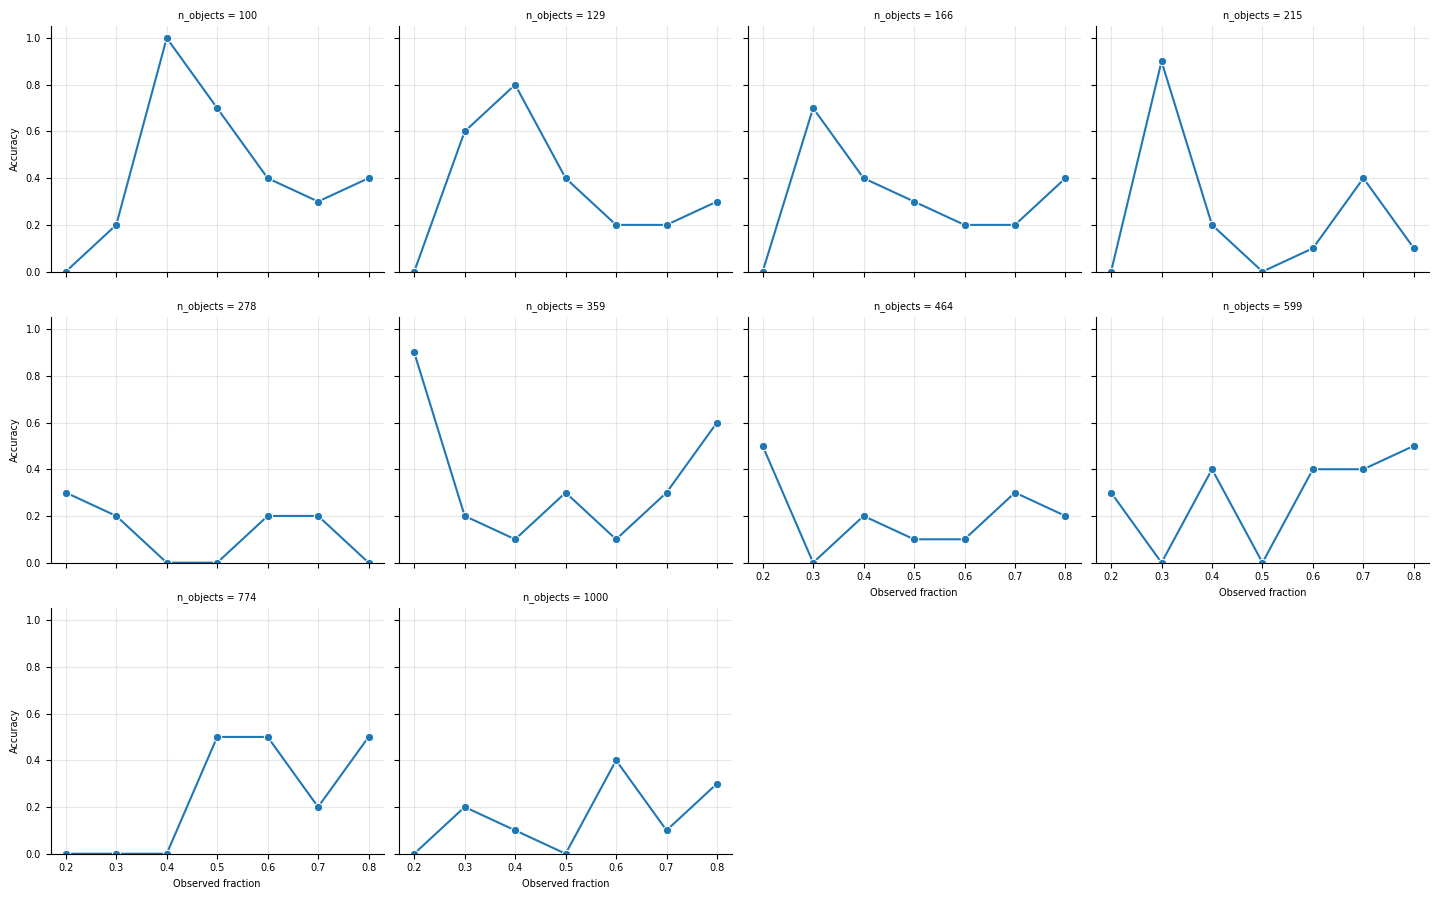

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load results
# df = pd.read_csv("../results/cross_validation/rank_detection.csv")
df = df_similarity[df_similarity["snr"] == 1.0]

# For each (n_objects, train_ratio, trial_id), find the rank with minimum mse
best_ranks = df.loc[
    df.groupby(["n_objects", "observed_fraction", "trial_id"])["mse"].idxmin()
]

# Add a column indicating whether the selected rank matches the true rank
best_ranks["correct_rank"] = (best_ranks["rank"] == best_ranks["true_rank"]).astype(int)

# Compute accuracy (fraction of correct rank selections) for each (n_objects, train_ratio)
accuracy = (
    best_ranks.groupby(["n_objects", "observed_fraction"])["correct_rank"]
    .mean()
    .reset_index()
    .rename(columns={"correct_rank": "accuracy"})
)

# Plot accuracy as a function of train_ratio, faceted by n_objects
g = sns.FacetGrid(
    accuracy,
    col="n_objects",
    col_wrap=4,
    sharey=True,
    height=3,
    aspect=1.2,
)
g.map_dataframe(sns.lineplot, x="observed_fraction", y="accuracy", marker="o")
g.set_axis_labels("Observed fraction", "Accuracy")
g.set_titles("n_objects = {col_name}")
for ax in g.axes.flatten():
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Checking the rank selection for eg DNNs etc

In [40]:
peterson = load_dataset("peterson-animals")
rsm = peterson.rsm

import numpy as np
from cross_validation import cross_val_score

df = cross_val_score(
    rsm,
    observed_fraction=0.6,
    n_repeats=100,
    param_grid={"rank": np.arange(2, 46, 2), "max_outer": [10], "max_inner": [20]},
)


Running 2200 jobs (22 params x 100 CV splits)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 144 concurrent workers.
[Parallel(n_jobs=-1)]: Done 162 tasks      | elapsed:   21.4s
[Parallel(n_jobs=-1)]: Done 512 tasks      | elapsed:   52.9s
[Parallel(n_jobs=-1)]: Done 962 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 1512 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 2200 out of 2200 | elapsed:  3.6min finished


In [44]:
from utils.helpers import compute_subsampling_fraction_symmetric

frac = compute_subsampling_fraction_symmetric(rsm, constant=0.01)


Effective rank: 45.006611759421894
Required samples: 1237.8660185526903
Degrees of freedom: 7260
Fraction of entries to sample: 0.17050496123315292


{'max_inner': np.int64(20), 'max_outer': np.int64(10), 'rank': np.int64(10)}


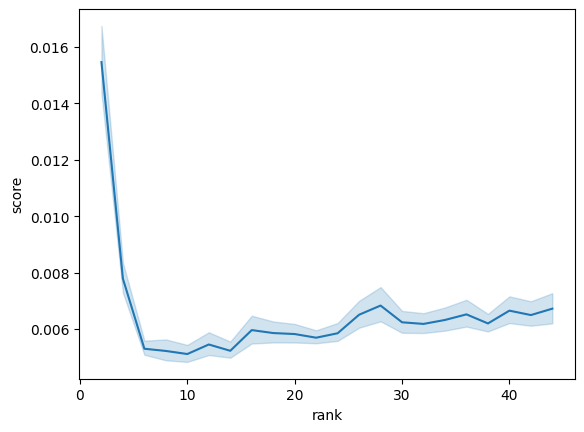

In [41]:
import matplotlib.pyplot as plt


cv = df.cv_results_

# print the best rank
print(df.best_params_)

sns.lineplot(data=cv, x="rank", y="score")
plt.show()


In [47]:
from experiments.things import compute_similarity_matrix_from_triplets, load_triplets
from utils.helpers import (
    estimate_effective_rank,
    compute_subsampling_fraction_symmetric,
)

train_triplets, val_triplets = load_triplets("../data/things")
sim = compute_similarity_matrix_from_triplets(1854, train_triplets)
sim = np.nan_to_num(sim, 0)  # replace nans with 0


In [48]:
cross_val_score(
    sim,
    observed_fraction=0.8,
    n_repeats=5,
    param_grid={"rank": np.arange(10, 80, 10), "max_outer": [15], "max_inner": [5]},
)


Running 35 jobs (7 params x 5 CV splits)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 144 concurrent workers.
[Parallel(n_jobs=-1)]: Done  35 out of  35 | elapsed:  3.1min finished
